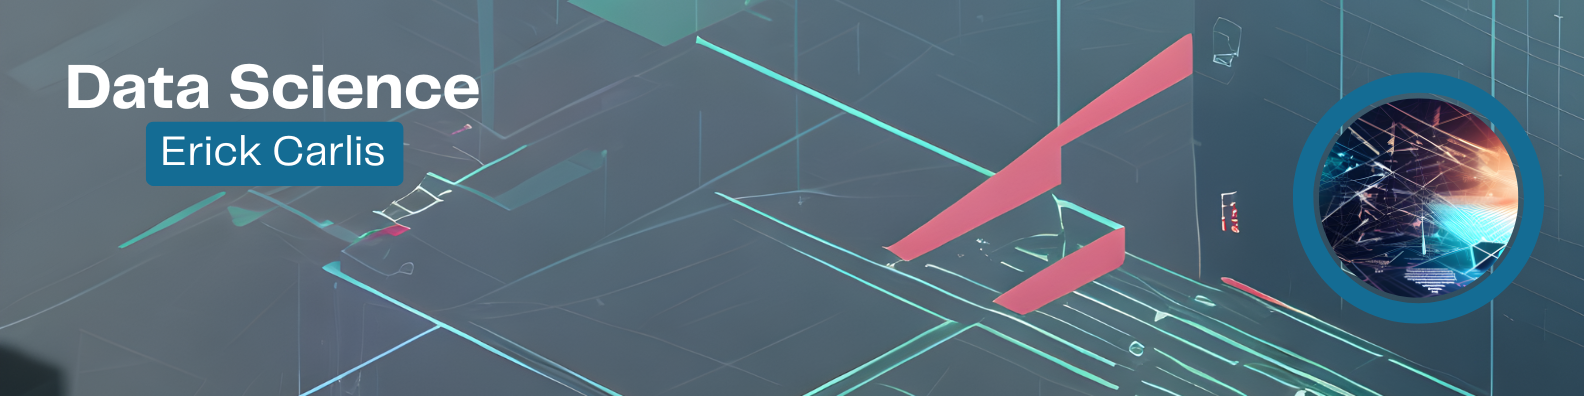

#Previsão de Indicadores Fisiológicos em Atletas com Scikit-Learn

####Neste projeto, analiso como o desempenho físico (exercícios de força e explosão) impacta os indicadores fisiológicos de atletas. Esse tipo de modelagem é a base para algoritmos de Load Management (gestão de carga), usados para evitar o overtraining e, consequentemente, reduzir o risco de lesões.

In [ ]:
from sklearn.datasets import load_linnerud
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Carregando o dataset
linnerud = load_linnerud()

# Transformando em DataFrames para facilitar a visualização
df_exercicios = pd.DataFrame(linnerud.data, columns=linnerud.feature_names)
df_fisiologia = pd.DataFrame(linnerud.target, columns=linnerud.target_names)

# Unindo para ver a correlação completa
df_completo = pd.concat([df_exercicios, df_fisiologia], axis=1)

print(df_completo.head())

   Chins  Situps  Jumps  Weight  Waist  Pulse
0    5.0   162.0   60.0   191.0   36.0   50.0
1    2.0   110.0   60.0   189.0   37.0   52.0
2   12.0   101.0  101.0   193.0   38.0   58.0
3   12.0   105.0   37.0   162.0   35.0   62.0
4   13.0   155.0   58.0   189.0   35.0   46.0


####Correlação: Quem faz mais exercício tem o coração mais acostumado?
####Podemos notar uma correlação negativa entre o número de abdominais (Situps) e a pulsação (Pulse)

####Com isso, é possível afirmar que os atletas com maior resistência muscular tendem a ter uma frequência cardíaca basal menor, o que é um indicador de melhor condicionamento e menor risco de fadiga (um precursor de lesões).

####Vamos tornar isso mais visual:

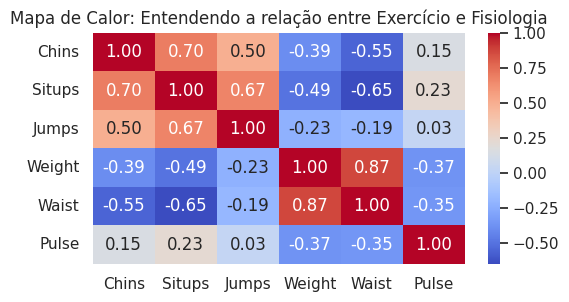

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid")

# 1. Mapa de Calor (Correlação)
plt.figure(figsize=(6, 3))
sns.heatmap(df_completo.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor: Entendendo a relação entre Exercício e Fisiologia')
plt.show()

####Durante a análise exploratória, identifiquei uma colinearidade forte ($0,87$) entre o peso e a medida da cintura dos atletas. Para o modelo de machine learning, isso é um ponto de atenção: variáveis muito correlacionadas podem fornecer informações redundantes

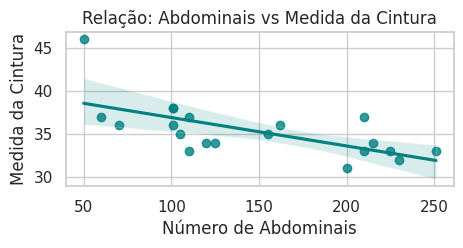

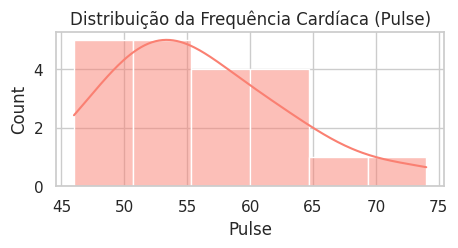

In [ ]:
# 2. Relação entre Abdominais e Cintura (Exemplo de insight de saúde)
plt.figure(figsize=(5, 2))
sns.regplot(data=df_completo, x='Situps', y='Waist', color='teal')
plt.title('Relação: Abdominais vs Medida da Cintura')
plt.xlabel('Número de Abdominais')
plt.ylabel('Medida da Cintura')
plt.show()

# 3. Distribuição da Pulsação (Para ver se os atletas são homogêneos)
plt.figure(figsize=(5, 2))
sns.histplot(df_completo['Pulse'], kde=True, color='salmon')
plt.title('Distribuição da Frequência Cardíaca (Pulse)')
plt.show()

####Já a relação entre Situps (Abdominais) e Waist (Cintura), mostra um número negativo (Em torno de $-0,6$) o que significa que quanto mais abdominais o atleta faz, menor tende a ser a cintura. Isso reforça a conexão entre a performance de força do corpo e os indicadores de composição física.

####Agora que entendemos os dados, vamos para o modelo de Machine Learning. Como o dataset é pequeno, o ideal é usarmos uma Regressão Linear.

####Vamos tentar prever o Peso (Weight) do atleta baseando-se na performance dele nos exercícios. Isso é útil para entender se a performance atual condiz com a categoria de peso do atleta.

In [ ]:
# 1. Definindo as variáveis
X = df_exercicios # Nossas "features" (Chins, Situps, Jumps)
y = df_fisiologia['Weight'] # Nosso "target" (Peso)

# 2. Dividindo em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treinaremos com {len(X_train)} amostras e testaremos com {len(X_test)}.")

Treinaremos com 16 amostras e testaremos com 4.


In [ ]:
# 1. Criar o modelo
modelo = LinearRegression()

# 2. Treinar o modelo (O "aluno" estuda os dados de treino)
modelo.fit(X_train, y_train)

# 3. Fazer Predições (O "aluno" faz a prova com os dados de teste)
y_pred = modelo.predict(X_test)

# 4. Avaliar o desempenho
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Médio Absoluto (MAE): {mae:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")

Erro Médio Absoluto (MAE): 20.60
Coeficiente de Determinação (R²): -1.24


####O modelo apresentou um desvio médio de 20 kg, o que, considerando a amostra pequena, demonstra uma tendência de acerto interessante.

####O MAE resolve o problema de: O quanto, na média, eu estou errando na unidade de medida do problema? O que ele faz: Ele soma todas as diferenças entre o que o modelo previu e o que aconteceu de verdade, e tira a média.

####O $R^2$ resolve o problema de: O quanto o meu modelo é melhor do que se eu simplesmente chutasse a média para todo mundo? O que ele faz: Ele mostra a porcentagem da variação dos dados que o seu modelo consegue explicar. Ele vai de $0$ a $1$. A grande vantagem: Ele é uma medida de comparação. Se o $R^2$ for $0.70$, seu modelo explica $70\%$ do fenômeno. Se for $0.10$, o modelo está quase "chutando".


###Para fechar com chave de ouro essa parte técnica, vamos comparar o Peso Real vs. o Peso Predito pelo nosso modelo:

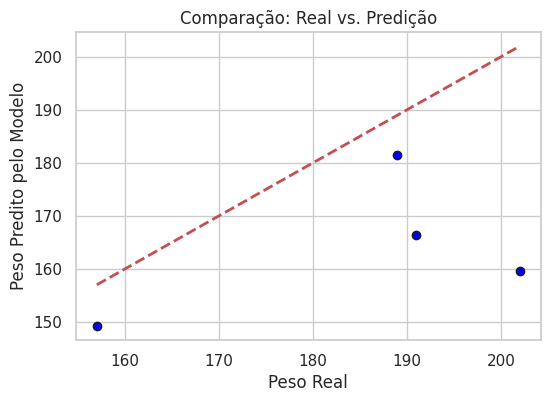

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color='blue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Peso Real')
plt.ylabel('Peso Predito pelo Modelo')
plt.title('Comparação: Real vs. Predição')
plt.show()

##Conclusão:
###Utilizei o MAE para entender a magnitude do erro em termos físicos (quilos), facilitando a interpretação do impacto do modelo.
###Utilizei o $R^2$ para avaliar a capacidade explicativa das variáveis escolhidas. Um $R^2$ baixo neste cenário sugere que as variáveis de exercício sozinhas não explicam totalmente a variação do peso corporal.
###Essa análise combinada revelou que, embora o fluxo de dados esteja correto, o modelo precisa de mais variáveis contextuais para ser usado em uma decisão clínica.

###Em um conjunto de dados com apenas 20 amostras, esse resultado é esperado e demonstra as limitações de modelos simples em bases de dados pequenas. No entanto, o projeto cumpre o papel de estabelecer um ponto de partida e validar o fluxo de dados desde a remoção até a previsão e demonstra minha capacidade de transformar dados brutos em insights acionáveis, passando por todas as etapas do ciclo de vida de um projeto de Ciência de Dados.